**GRU**

**Keras** **GRU**

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [3]:
df = pd.read_csv('Truck_sales.csv')
print(df.head())
print(df.info())

sales = df['Number_Trucks_Sold'].values.reshape(-1, 1)

  Month-Year  Number_Trucks_Sold
0     03-Jan                 155
1     03-Feb                 173
2     03-Mar                 204
3     03-Apr                 219
4     03-May                 223
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Month-Year          144 non-null    object
 1   Number_Trucks_Sold  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None


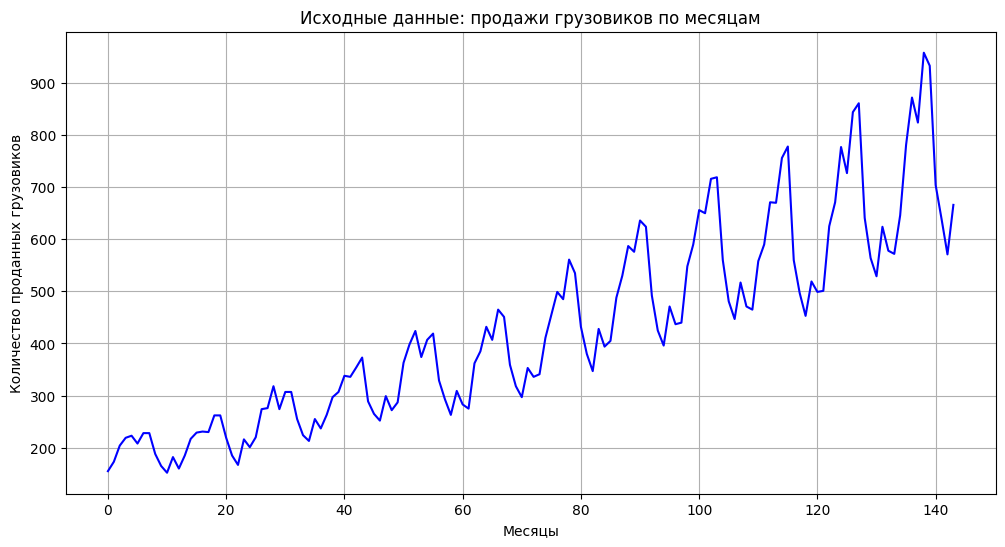

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(sales, color='blue')
plt.title('Исходные данные: продажи грузовиков по месяцам')
plt.xlabel('Месяцы')
plt.ylabel('Количество проданных грузовиков')
plt.grid(True)
plt.show()

In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))
sales_scaled = scaler.fit_transform(sales)

In [6]:
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps, 0])
        y.append(data[i+n_steps, 0])
    return np.array(X), np.array(y)

n_steps = 12
X, y = create_sequences(sales_scaled, n_steps)

In [7]:
test_size = 24
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [14]:
model = Sequential([
    GRU(100, return_sequences=True, activation='tanh', input_shape=(n_steps, 1)),
    Dropout(0.2),
    GRU(100, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 12, 100)        │        30,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 100)            │        60,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,601 (357.82 KB)

 Trainable params: 91,601 (357.82 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=1)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0409
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0194
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0142 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0100
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0107 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0102
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0099
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0104
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0097
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0093
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0101
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0077
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0077
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0084
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0085
Epoch 16/100
7/7 ━━

In [16]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

r2 = r2_score(y_true, y_pred)
print(f'R² на тестовой выборке: {r2:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
R² на тестовой выборке: 0.8352


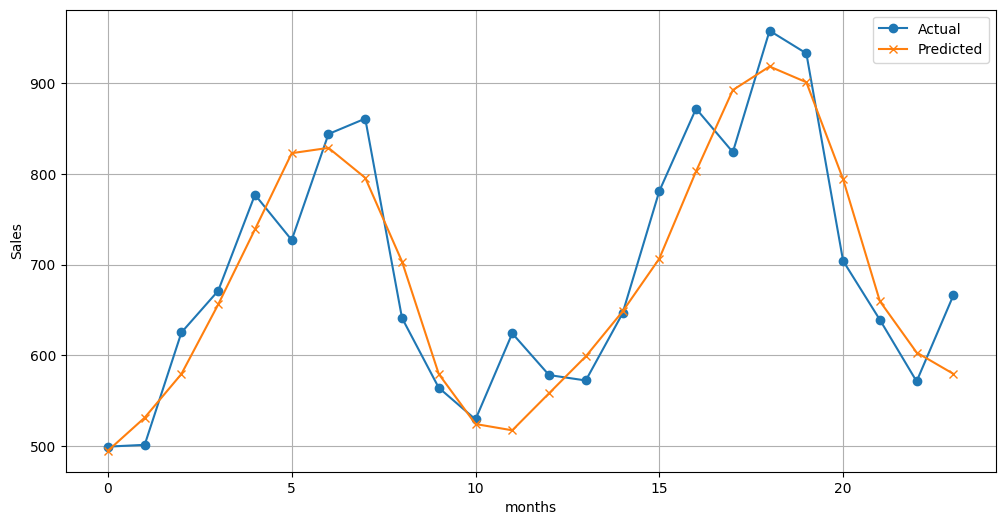

In [17]:
plt.figure(figsize=(12,6))
plt.plot(y_true, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.legend()
plt.xlabel('months')
plt.ylabel('Sales')
plt.grid(True)
plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


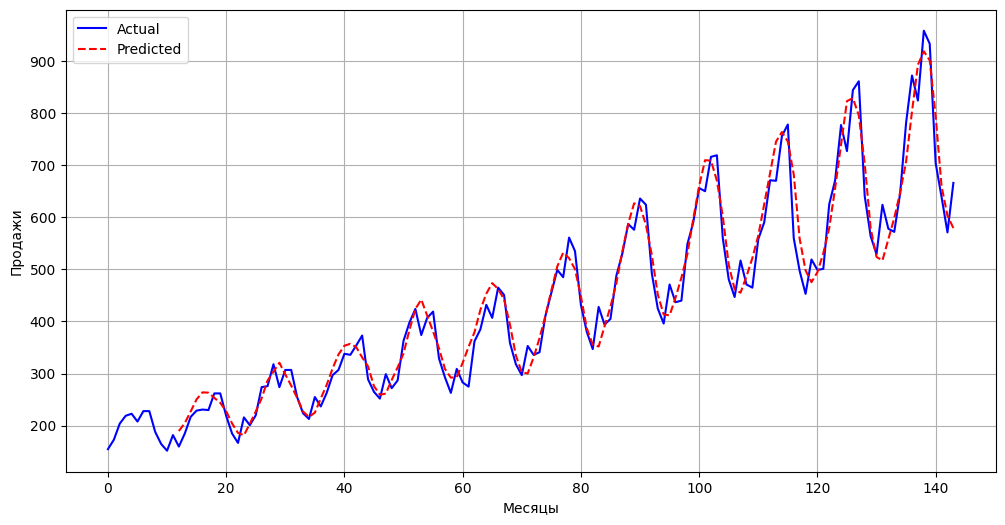

In [18]:
X_all = X.reshape((X.shape[0], X.shape[1], 1))
y_all_pred_scaled = model.predict(X_all)
y_all_pred = scaler.inverse_transform(y_all_pred_scaled)

y_all_actual = scaler.inverse_transform(y.reshape(-1, 1))

plt.figure(figsize=(12,6))
plt.plot(sales, label='Actual', color='blue')
plt.plot(range(n_steps, len(sales)), y_all_pred, label='Predicted', color='red', linestyle='--')
plt.xlabel('Месяцы')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True)
plt.show()

**TORCH**

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [20]:
test_size = 24
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

In [21]:
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

In [22]:
print(f"X_train shape: {X_train.shape}")

X_train shape: torch.Size([108, 12, 1])


In [32]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

In [33]:
model2 = GRUModel(input_size=1, hidden_size=64, output_size=1, num_layers=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

In [34]:
batch_size = 16
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

epochs = 200
loss_history = []

In [35]:
model2.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model2(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    epoch_loss /= len(train_loader.dataset)
    loss_history.append(epoch_loss)
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.6f}')


Epoch [20/200], Loss: 0.007918
Epoch [40/200], Loss: 0.005250
Epoch [60/200], Loss: 0.003785
Epoch [80/200], Loss: 0.001860
Epoch [100/200], Loss: 0.002328
Epoch [120/200], Loss: 0.001723
Epoch [140/200], Loss: 0.001421
Epoch [160/200], Loss: 0.001433
Epoch [180/200], Loss: 0.001227
Epoch [200/200], Loss: 0.001099


In [36]:
model2.eval()
with torch.no_grad():
    y_pred_scaled = model2(X_test).numpy()
    y_true_scaled = y_test.numpy()

In [37]:
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_true_scaled)

r2 = r2_score(y_true, y_pred)
print(f'R² на тестовой выборке: {r2:.4f}')

R² на тестовой выборке: 0.6684


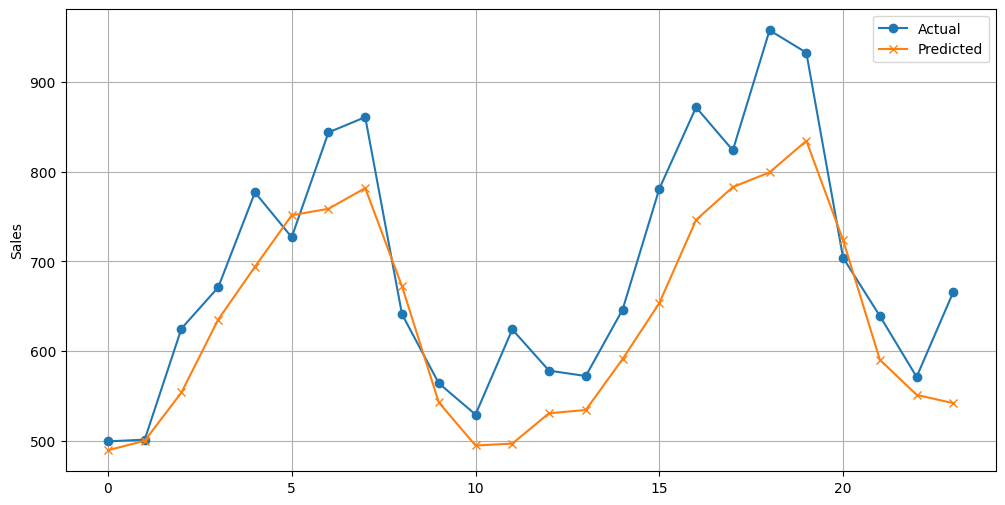

In [53]:
plt.figure(figsize=(12,6))
plt.plot(y_true, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.legend()
plt.ylabel('Sales')
plt.grid(True)
plt.show()

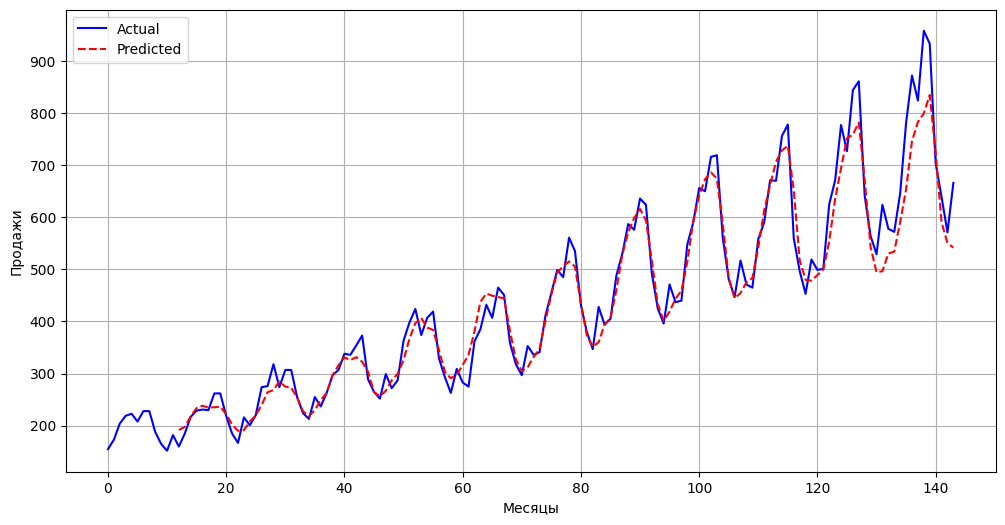

In [39]:
X_all = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (samples, 12, 1)
with torch.no_grad():
    y_all_pred_scaled = model2(X_all).numpy()
y_all_pred = scaler.inverse_transform(y_all_pred_scaled)

plt.figure(figsize=(12,6))
plt.plot(sales, label='Actual', color='blue')
plt.plot(range(n_steps, len(sales)), y_all_pred, label='Predicted', color='red', linestyle='--')
plt.xlabel('Месяцы')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True)
plt.show()

**LSTM**

**Keras**

In [40]:
from tensorflow.keras.layers import LSTM, Dropout


In [41]:
model3 = Sequential([
    LSTM(100, return_sequences=True, input_shape=(n_steps, 1)),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(1)
])

model3.compile(optimizer='adam', loss='mse')
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,301 (493.36 KB)

 Trainable params: 126,301 (493.36 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history3 = model3.fit(X_train, y_train, epochs=150, batch_size=16, verbose=1, validation_split=0.1)


Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - loss: 0.0768 - val_loss: 0.0577
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0192 - val_loss: 0.0229
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0113 - val_loss: 0.0367
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0096 - val_loss: 0.0215
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0100 - val_loss: 0.0216
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0120 - val_loss: 0.0215
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0110 - val_loss: 0.0262
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0101 - val_loss: 0.0296
Epoch 9/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0144 - val_loss: 0.0216
Epoch 10/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0101 - val_loss: 0.0281
Epoch 11/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0131 - val_loss: 0.0202
Epoch 12/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0154 - val_l

In [43]:
y_pred_scaled3 = model3.predict(X_test)
y_pred3 = scaler.inverse_transform(y_pred_scaled3)
y_true3 = scaler.inverse_transform(y_test.reshape(-1, 1))
r2_3 = r2_score(y_true3, y_pred3)
print(f'R² (Keras LSTM): {r2_3:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
R² (Keras LSTM): 0.7730


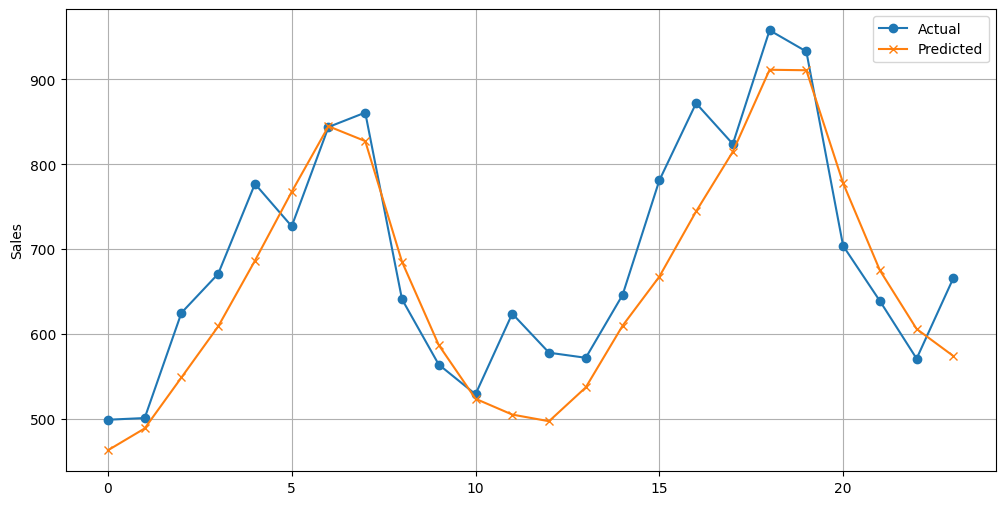

In [52]:
plt.figure(figsize=(12,6))
plt.plot(y_true3, label='Actual', marker='o')
plt.plot(y_pred3, label='Predicted', marker='x')
plt.legend()
plt.ylabel('Sales')
plt.grid(True)
plt.show()


**TORCH**

In [45]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, output_size=1, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

model4 = LSTMModel(input_size=1, hidden_size=100, output_size=1, num_layers=2, dropout=0.2)
criterion = nn.MSELoss()
optimizer = optim.Adam(model4.parameters(), lr=0.001)

In [46]:
batch_size = 16
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

epochs = 150
loss_history4 = []

In [47]:
model4.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model4(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    epoch_loss /= len(train_loader.dataset)
    loss_history4.append(epoch_loss)
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.6f}')

Epoch [20/150], Loss: 0.009125
Epoch [40/150], Loss: 0.007251
Epoch [60/150], Loss: 0.005429
Epoch [80/150], Loss: 0.005472
Epoch [100/150], Loss: 0.002496
Epoch [120/150], Loss: 0.001864
Epoch [140/150], Loss: 0.001760


In [48]:
model4.eval()
with torch.no_grad():
    y_pred_scaled4 = model4(X_test).numpy()
y_pred4 = scaler.inverse_transform(y_pred_scaled4)
r2_4 = r2_score(y_true3, y_pred4)  # y_true3 уже вычислено выше
print(f'R² (PyTorch LSTM): {r2_4:.4f}')

R² (PyTorch LSTM): 0.6819


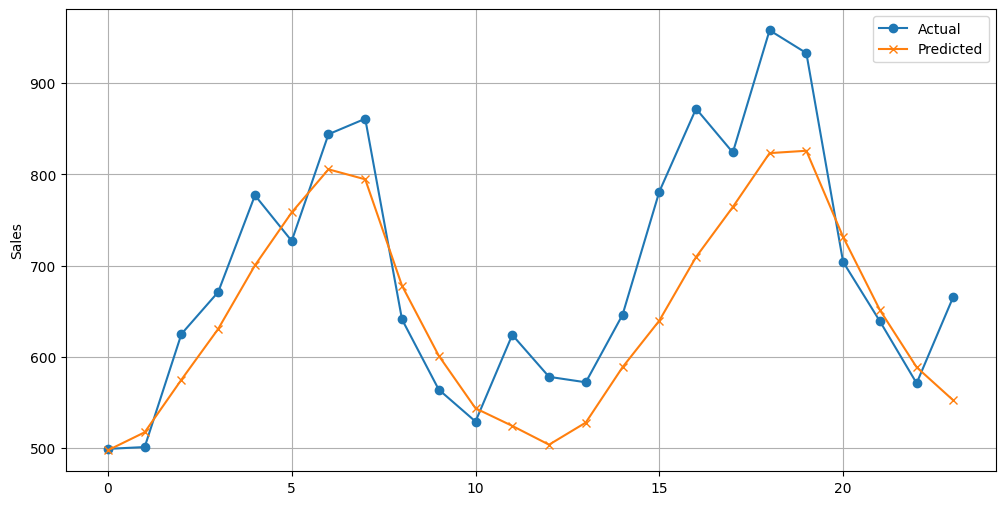

In [51]:
plt.figure(figsize=(12,6))
plt.plot(y_true3, label='Actual', marker='o')
plt.plot(y_pred4, label='Predicted', marker='x')
plt.legend()
plt.ylabel('Sales')
plt.grid(True)
plt.show()

**Ручной GRU (без помощи нейросетей не обошлось)**

In [64]:
class ManualGRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size

        # Веса для вентиля обновления (z)
        self.Wz = nn.Linear(input_size, hidden_size, bias=True)
        self.Uz = nn.Linear(hidden_size, hidden_size, bias=False)
        # Веса для вентиля сброса (r)
        self.Wr = nn.Linear(input_size, hidden_size, bias=True)
        self.Ur = nn.Linear(hidden_size, hidden_size, bias=False)
        # Веса для кандидата (h_tilde)
        self.Wh = nn.Linear(input_size, hidden_size, bias=True)
        self.Uh = nn.Linear(hidden_size, hidden_size, bias=False)
        # Выходной слой (преобразует последнее состояние в прогноз)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_size)   # начальное состояние
        for t in range(seq_len):
            x_t = x[:, t, :]                     # текущий вход
            # Вычисляем вентили
            z = torch.sigmoid(self.Wz(x_t) + self.Uz(h))   # обновление
            r = torch.sigmoid(self.Wr(x_t) + self.Ur(h))   # сброс
            # Кандидатное состояние
            h_tilde = torch.tanh(self.Wh(x_t) + self.Uh(r * h))
            # Новое состояние: смешиваем старое и кандидата
            h = (1 - z) * h + z * h_tilde
        # Берём последнее состояние и делаем прогноз
        out = self.fc(h)
        return out

In [66]:
model5 = ManualGRU(input_size=1, hidden_size=32, output_size=1)

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model5.parameters(), lr=0.001)

In [67]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)


In [68]:
epochs = 150
loss_history5 = []
model5.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model5(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    epoch_loss /= len(train_loader.dataset)
    loss_history5.append(epoch_loss)
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.6f}')

Epoch [20/150], Loss: 0.004742
Epoch [40/150], Loss: 0.003731
Epoch [60/150], Loss: 0.003143
Epoch [80/150], Loss: 0.002785
Epoch [100/150], Loss: 0.002451
Epoch [120/150], Loss: 0.002026
Epoch [140/150], Loss: 0.001818


In [69]:
model5.eval()
with torch.no_grad():
    y_pred_scaled = model5(X_test).numpy()
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.numpy())


In [70]:
r2 = r2_score(y_true, y_pred)
print(f'R² (ручной GRU, model5): {r2:.4f}')

R² (ручной GRU, model5): 0.4699


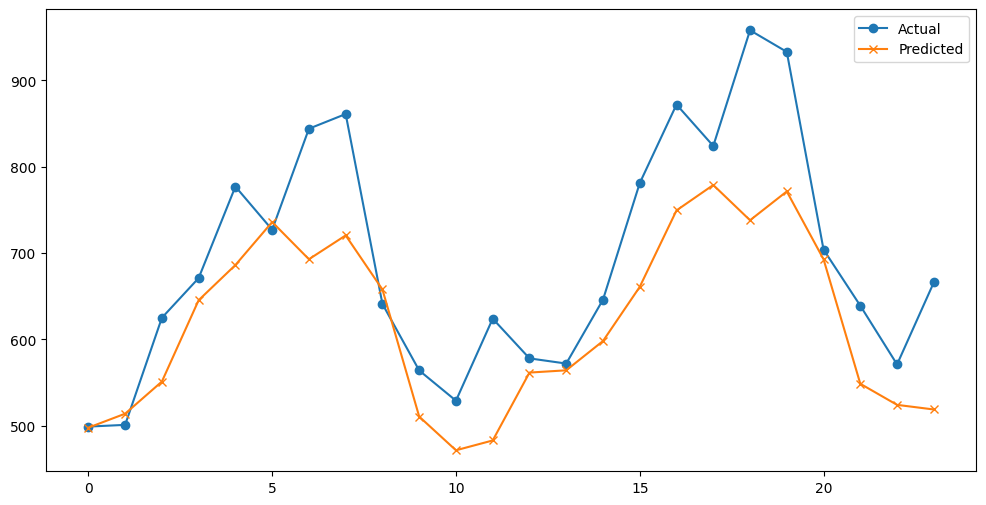

In [71]:
plt.figure(figsize=(12,6))
plt.plot(y_true, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.legend()
plt.show()